In [1]:
import pymc as pm
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import matplotlib.cm as cm
import pandas as pd
import pytensor.tensor as pt
import json

#Make sure it can see the system path

# import sys
# from pathlib import Path

# PROJECT_ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
# sys.path.insert(0, str(PROJECT_ROOT))
import sys
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

In [2]:
from utils import load_data,plot_helpers
#reload(load_data)
from modeling import bayes


In [3]:
for_paper=True
for_talk=False

if for_paper:
    plt.style.use('seaborn-v0_8-paper')
    
elif for_talk:
    plt.style.use("dark-background")
else:
    az.style.use("arviz-doc")
    
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

save_figs=True
FIG_DIR = "../Writeup/Response/NEWFIGS/"

In [4]:
from utils.plot_helpers import *

In [5]:
carbon_cycle_evidence=load_data.load_carbon_cycle()


In [6]:
feedback_evidence=load_data.feedback_dictionary(generation="CMIP6")

In [7]:
temperature_evidence={}
temperature_evidence["T2000"]=load_data.load_temperature(2000)

In [8]:
evidence = carbon_cycle_evidence | feedback_evidence | temperature_evidence

# Observations
Use GISTEMP and HadCRUT global mean temperature observations.  Assume the reported ensembles are samples from some posterior.

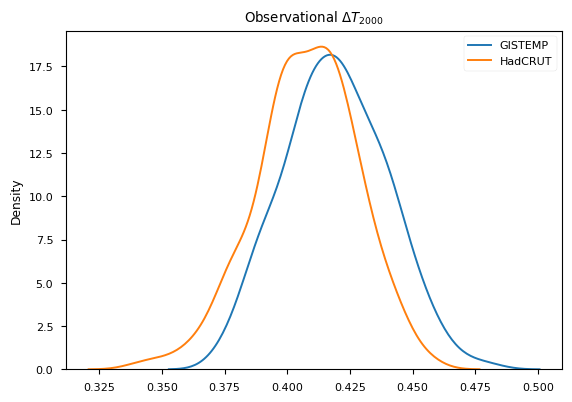

In [10]:
#Observations
hadcrut_file=\
DATA_DIR/"global_mean_T/HadCRUT.5.0.2.0.analysis.ensemble_series.global.annual.nc"
hadcrut=xr.open_dataset(hadcrut_file).tas
hadcrut= hadcrut-\
hadcrut.sel(time=slice("1951-1-1","1980-12-31")).mean(dim="time")

gistemp_file=DATA_DIR/"global_mean_T/ensembleCombinedSeries_Global.nc"
gistemp=xr.open_dataset(gistemp_file).tas.groupby("time.year").mean(dim="time")


gistemp_2000=gistemp.sel(year=2000).values

hadcrut_2000=hadcrut.sel(time=slice("2000-1-1","2000-12-31")).mean(dim="time")-\
hadcrut.sel(time=slice("1951-1-1","1980-12-31")).mean(dim="time").values
tmp=sns.kdeplot(gistemp_2000,label="GISTEMP")
tmp=sns.kdeplot(hadcrut_2000,label="HadCRUT")
plt.legend()
tmp=plt.title(r"Observational $\Delta T_{2000}$")

In [11]:
def add_temperature_observations(model,var_name,observations=None,sigma_obs_iv=0.1,obs_name="GISTEMP"):
    with model:
        if "actual" not in model.named_vars:
            T_realized = pm.Normal("actual",model[var_name],sigma_obs_iv)
        if observations is not None:
            # assume observations is an ensemble of posterior draws
            T_obs = pm.Normal(obs_name,mu=model["actual"],sigma=observations.std(),observed=observations)

# What is the externally forced contribution to the temperature anomaly in 2000?

In the CMIP models:
$$T_i^j \sim N(T_i,\sigma_i)$$
(Each ensemble member j is the forced response T_i in the ESM i plus internal variability in ESM_i)

The forced responses vary structurally across the models
$$T_i \sim N(T_f,\sigma_{struct})$$

The observations are 
$$T_{2000} = T_f + \epsilon $$
where $T_f$ is the forced response and $\epsilon$ the internal variability

### Fixed effects, wide priors

In [12]:

with bayes.build_fixed_effects_model(evidence["T2000"],var_name="T2000",
                               priors={"T2000":lambda name:pm.Normal(0,100)}) as fixmodel:
    actual = pm.Normal("actual",fixmodel["T2000"],sigma=0.1) # add the actual T_realized for later
    trace_fix=pm.sample()

 Progress                    Draw   Divergences   Step size   Grad evals   Speed             Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.191       3            5179.41 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.716       3            4723.08 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.961       3            4058.24 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.190       3            3788.24 draws/s   0:00:00   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Now add the observations to compare the updates (fixobs) with the CMIP-only posterior (trace_fix).  

In [13]:
with fixmodel:
    add_temperature_observations(fixmodel,"T2000",observations=hadcrut_2000.values,\
                                 sigma_obs_iv=0.1,obs_name="HadCRUT")
    add_temperature_observations(fixmodel,"T2000",observations=gistemp_2000,\
                                 sigma_obs_iv=0.1,obs_name="Gistemp")
    fixobs=pm.sample()

 Progress                    Draw   Divergences   Step size   Grad evals   Speed             Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.357       3            3571.96 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.106       3            3258.55 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.243       3            2944.82 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.757       3            2767.97 draws/s   0:00:00   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


### Fixed effects, narrow (wrong) priors

In [14]:

with bayes.build_fixed_effects_model(evidence["T2000"],var_name="T2000",\
                               priors={"T2000":lambda name:pm.Normal(0,0.01)}) as fixmodel_tight:
    actual = pm.Normal("actual",fixmodel_tight["T2000"],sigma=0.1) # add the actual T_realized for later
    trace_fix_tight=pm.sample()

 Progress                    Draw   Divergences   Step size   Grad evals   Speed             Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.060       3            5119.42 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.135       3            4603.60 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.901       3            4077.11 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.029       3            3709.75 draws/s   0:00:00   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Now add the observations to compare the updates (fixobs_tight) with the CMIP-only posterior (trace_fix_tight).  

In [15]:
with fixmodel_tight:
    add_temperature_observations(fixmodel_tight,"T2000",observations=hadcrut_2000.values,\
                                 sigma_obs_iv=0.1,obs_name="HadCRUT")
    add_temperature_observations(fixmodel_tight,"T2000",observations=gistemp_2000,\
                                 sigma_obs_iv=0.1,obs_name="Gistemp")
    fixobs_tight=pm.sample()

 Progress                    Draw   Divergences   Step size   Grad evals   Speed             Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.952       3            3736.86 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.976       3            3546.88 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.207       3            3174.63 draws/s   0:00:00   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             1.215       3            2963.36 draws/s   0:00:00   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


###  Random effects, narrow priors

In [16]:
# calculate trace for rho = 0
var_name="T2000"
priors0={}
priors0["rho"] = lambda name:0.0
priors0["T2000"] = lambda name: pm.Normal(name,0,100)

with bayes.build_correlated_random_effects_model(data = \
                                           evidence[var_name],priors=priors0,var_name=var_name) as model_0:
    actual = pm.Normal("actual",model_0["T2000"],sigma=0.1) # add the actual T_realized for later
    # Using an uncorrelated random effects model, sample the trace for forced and realized T2000
    trace_0=pm.sample(target_accept=.99)
  

 Progress                     Draw   Divergences   Step size   Grad evals   Speed            Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.050       63           304.11 draws/s   0:00:06   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.044       63           296.51 draws/s   0:00:06   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.056       63           313.18 draws/s   0:00:06   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.056       63           306.16 draws/s   0:00:06   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Add the observations

In [17]:
with model_0:
    add_temperature_observations(model_0,"T2000",observations=hadcrut_2000.values,\
                                 sigma_obs_iv=0.1,obs_name="HadCRUT")
    add_temperature_observations(model_0,"T2000",observations=gistemp_2000,\
                                 sigma_obs_iv=0.1,obs_name="Gistemp")
    obs_0=pm.sample(target_accept=.95)

 Progress                     Draw   Divergences   Step size   Grad evals   Speed            Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.112       31           469.07 draws/s   0:00:04   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.092       63           457.70 draws/s   0:00:04   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.108       63           468.35 draws/s   0:00:04   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.109       31           459.63 draws/s   0:00:04   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


In [18]:
# calculate trace for rho = 0, tight (wrong) priors
var_name="T2000"
priors0t={}
priors0t["rho"] = lambda name:0.0
priors0t["T2000"] = lambda name: pm.Normal(name,0,.01)

with bayes.build_correlated_random_effects_model(data = \
                                           evidence[var_name],priors=priors0t,var_name=var_name) as model_0_tight:
    actual = pm.Normal("actual",model_0_tight["T2000"],sigma=0.1) # add the actual T_realized for later
    # Using an uncorrelated random effects model, sample the trace for forced and realized T2000
    trace_0_tight=pm.sample(target_accept=.99)
  

 Progress                     Draw   Divergences   Step size   Grad evals   Speed            Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.019       127          189.61 draws/s   0:00:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.025       127          181.05 draws/s   0:00:11   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.024       127          192.98 draws/s   0:00:10   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   0             0.024       127          183.72 draws/s   0:00:10   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [19]:
with model_0_tight:
    add_temperature_observations(model_0_tight,"T2000",observations=hadcrut_2000.values,\
                                 sigma_obs_iv=0.1,obs_name="HadCRUT")
    add_temperature_observations(model_0_tight,"T2000",observations=gistemp_2000,\
                                 sigma_obs_iv=0.1,obs_name="Gistemp")
    obs_0_tight=pm.sample()

 Progress                     Draw   Divergences   Step size   Grad evals   Speed            Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   4             0.070       63           370.59 draws/s   0:00:05   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   4             0.068       63           380.71 draws/s   0:00:05   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   3             0.079       63           384.07 draws/s   0:00:05   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━━   2000   46            0.050       127          406.47 draws/s   0:00:04   0:00:00

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There were 57 divergences after tuning. Increase `target_accept` or reparameterize.


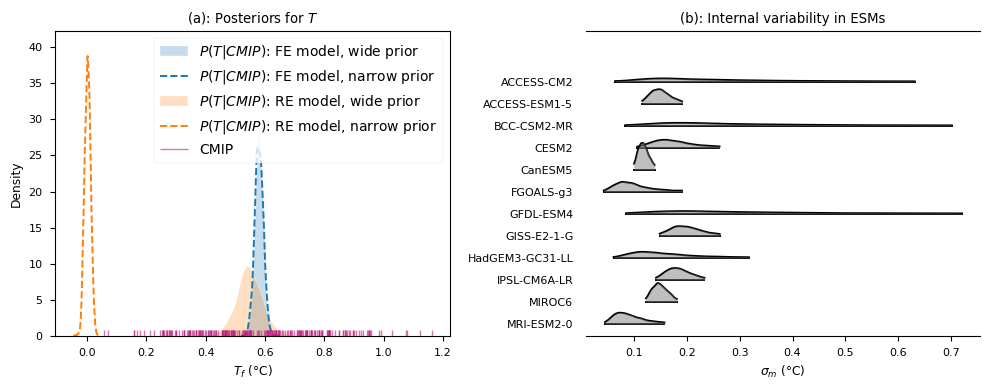

In [26]:
# Posteriors
plt.figure(figsize=(10,4))
#plot_posterior(trace_fix,"actual",label="fix Actual")
ax=plt.subplot(121)
plot_helpers.plot_posterior(trace_fix,"T2000",label=r"$P(T|CMIP)$: FE model, wide prior",ax=ax,\
                           fill=True,edgecolor="w")
plot_helpers.plot_posterior(trace_fix_tight,"T2000",\
                            label=r"$P(T|CMIP)$: FE model, narrow prior",color=colors[0],ls="--",ax=ax)
plot_helpers.plot_posterior(trace_0,"T2000",color=colors[1],label=r"$P(T|CMIP)$: RE model, wide prior",ax=ax,\
                           fill=True,edgecolor="w")
plot_helpers.plot_posterior(trace_0_tight,"T2000",\
                            color=colors[1],label=r"$P(T|CMIP)$: RE model, narrow prior",ax=ax,ls="--")
# plt.legend()
sns.rugplot(evidence["T2000"],c="k",label="CMIP",alpha=.6,height=0.02,color=cm.PiYG(.1))

# plot_posterior(trace_fix,"T2000",label=r"$P(T_f|CMIP6, M_{fix})$",ax=ax)
# #plot_posterior(trace_0,"actual",label="RE Actual")
# plot_posterior(trace_0,"T2000",label=r"$P(T_f|CMIP6, M_{R})$",ax=ax)
plt.legend(fontsize=10)
plt.xlabel(r"$T_f$ (°C)")

ax2=plt.subplot(122)
az.plot_forest(trace_0,var_names=["sigma_iv"],kind="ridgeplot",combined=True,\
               ridgeplot_alpha=.5,ridgeplot_overlap=1,ax=ax2,colors="gray")
ax2.set_yticklabels(np.unique(evidence["T2000"].model)[::-1])
ax2.set_xlabel("$\sigma_{m}$ (°C)")
ax2.set_title("(b): Internal variability in ESMs")
ax.set_title(r"(a): Posteriors for $T$")
plt.tight_layout()

if savefigs:
    plt.savefig(FIG_DIR / "New_Figure1.png")
# if for_paper:
#     plt.savefig(PROJECT_ROOT / "FIGS/T2000.pdf")

In [ ]:
# The rE and fixed effects models calculate the forced response.   Put back in internal variability to get the expected realized.

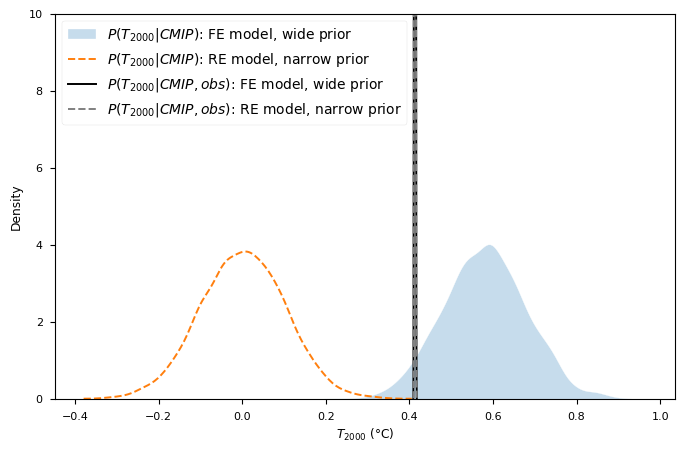

In [34]:
fig=plt.figure(figsize=(8,5))
ax=plt.subplot(111)
plot_helpers.plot_posterior(trace_fix,"actual",label=r"$P(T_{2000}|CMIP)$: FE model, wide prior",ax=ax,\
                           fill=True,edgecolor="w")
# plot_helpers.plot_posterior(trace_fix_tight,"actual",\
#                             label=r"$P(T_{2000}|CMIP6, M_{fix})$, narrow prior",color=colors[0],ls="--",ax=ax)
# plot_helpers.plot_posterior(trace_0,"actual",color=colors[1],label=r"$P(T_f|CMIP6, M_{R})$, wide prior",ax=ax,\
#                            fill=True)
plot_helpers.plot_posterior(trace_0_tight,"actual",\
                            color=colors[1],label=r"$P(T_{2000}|CMIP)$: RE model, narrow prior",ax=ax,ls="--")


plot_helpers.plot_posterior(fixobs,"actual",label=r"$P(T_{2000}|CMIP,obs)$: FE model, wide prior",ax=ax,\
                           fill=False,c="k")
# plot_helpers.plot_posterior(fixobs_tight,"actual",\
#                             label=r"$P(T_{2000}|CMIP6, M_{fix},obs)$, narrow prior",color=colors[-1],ls="--",ax=ax)
# plot_helpers.plot_posterior(obs_0,"actual",color=colors[-2],label=r"$P(T_f|CMIP6, M_{R},obs)$, wide prior",ax=ax,\
#                            fill=True)
plot_helpers.plot_posterior(obs_0_tight,"actual",\
                            label=r"$P(T_{2000}|CMIP, obs)$: RE model, narrow prior",\
                            ax=ax,\
                            ls="--",c="gray")
#plt.legend(fontsize=4)
plt.legend(fontsize=10,loc="upper left")
plt.ylim(0,10)
plt.xlabel(r"$T_{2000}$ (°C)")
if savefigs:
    plt.savefig(FIG_DIR / "New_Figure4.png")
# if for_paper:
#     plt.savefig(PROJECT_ROOT/"FIGS/T_obs.pdf")